PIZZA ANALYSIS

In [1]:
from google.colab import files
files = files.upload()

Saving pizza_sales_excel_file.xlsx to pizza_sales_excel_file.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel("pizza_sales_excel_file.xlsx")

# Exploratory Data Analysis (EDA)

**Dataset Overview**

In [4]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,The Classic Deluxe Pizza
2,3,2,five_cheese_l,2,2015-01-01,11:57:40,18.50,37.00,L,Veggie,The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,The Mexicana Pizza


In [5]:
df.shape

(48620, 11)

In [6]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_name'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   pizza_id        48620 non-null  int64         
 1   order_id        48620 non-null  int64         
 2   pizza_name_id   48620 non-null  object        
 3   quantity        48620 non-null  int64         
 4   order_date      48620 non-null  datetime64[ns]
 5   order_time      48620 non-null  object        
 6   unit_price      48620 non-null  float64       
 7   total_price     48620 non-null  float64       
 8   pizza_size      48620 non-null  object        
 9   pizza_category  48620 non-null  object        
 10  pizza_name      48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 4.1+ MB


In [8]:
df.isnull().sum()

,0
pizza_id,0
order_id,0
pizza_name_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


In [9]:
df.duplicated().sum()

np.int64(0)

Create a Backup Copy

In [10]:
df_clean = df.copy()

In [11]:
df_clean.dtypes

,0
pizza_id,int64
order_id,int64
pizza_name_id,object
quantity,int64
order_date,datetime64[ns]
order_time,object
unit_price,float64
total_price,float64
pizza_size,object
pizza_category,object


In [12]:
df_clean['order_time'] = pd.to_datetime(df_clean['order_time'] , format = '%H:%M:%S')

In [13]:
df_clean.dtypes

,0
pizza_id,int64
order_id,int64
pizza_name_id,object
quantity,int64
order_date,datetime64[ns]
order_time,datetime64[ns]
unit_price,float64
total_price,float64
pizza_size,object
pizza_category,object


In [14]:
df_clean.describe()

,pizza_id,order_id,quantity,order_date,order_time,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620,48620,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.038606,2015-06-29 11:03:43.611682560,1900-01-01 16:24:51.322151424,16.494132,17.135964
min,1.000000,1.000000,1.000000,2015-01-01 00:00:00,1900-01-01 09:52:21,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,2015-03-31 00:00:00,1900-01-01 13:24:46,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,2015-06-28 00:00:00,1900-01-01 16:33:33,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,2015-09-28 00:00:00,1900-01-01 18:55:19,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,2015-12-31 00:00:00,1900-01-01 23:05:52,35.950000,102.000000
std,14035.529381,6180.119770,0.234542,NaN,NaN,3.621789,5.491890


In [15]:
df_clean.describe(include = 'object')

,pizza_name_id,pizza_size,pizza_category,pizza_name
count,48620,48620,48620,48620
unique,91,5,4,32
top,big_meat_s,L,Classic,The Classic Deluxe Pizza
freq,1811,18526,14579,2416


**Unique Values Exploration**

Find the number of unique orders.

In [16]:
unique_orders = df_clean['order_id'].nunique()
print(f"Number of unique orders: {unique_orders}")

Number of unique orders: 21350


Find the number of unique pizzas.

In [17]:
unique_pizzas = df_clean['pizza_name'].nunique()
print(f"Number of unique pizzas: {unique_pizzas}")

Number of unique pizzas: 32


In [18]:
unique_pizzas = df_clean['pizza_name'].unique()
print(f"Number of unique pizzas: {unique_pizzas}")

Number of unique pizzas: ['The Hawaiian Pizza' 'The Classic Deluxe Pizza' 'The Five Cheese Pizza'
 'The Italian Supreme Pizza' 'The Mexicana Pizza' 'The Thai Chicken Pizza'
 'The Prosciutto and Arugula Pizza' 'The Barbecue Chicken Pizza'
 'The Greek Pizza' 'The Spinach Supreme Pizza' 'The Green Garden Pizza'
 'The Italian Capocollo Pizza' 'The Spicy Italian Pizza'
 'The Spinach Pesto Pizza' 'The Vegetables + Vegetables Pizza'
 'The Southwest Chicken Pizza' 'The California Chicken Pizza'
 'The Pepperoni Pizza' 'The Chicken Pesto Pizza' 'The Big Meat Pizza'
 'The Soppressata Pizza' 'The Four Cheese Pizza' 'The Napolitana Pizza'
 'The Calabrese Pizza' 'The Italian Vegetables Pizza'
 'The Mediterranean Pizza' 'The Pepper Salami Pizza'
 'The Spinach and Feta Pizza' 'The Sicilian Pizza'
 'The Chicken Alfredo Pizza' 'The Pepperoni, Mushroom, and Peppers Pizza'
 'The Brie Carre Pizza']


Find all unique pizza categories.

In [19]:
unique_pizza_category = df_clean['pizza_category'].nunique()
print(f"Unique Pizza Categories: {unique_pizza_category}")

Unique Pizza Categories: 4


In [20]:
unique_pizza_category = df_clean['pizza_category'].unique()
print(f"Unique Pizza Categories: {unique_pizza_category}")

Unique Pizza Categories: ['Classic' 'Veggie' 'Supreme' 'Chicken']


Find all available pizza sizes.

In [21]:
pizza_size = df_clean['pizza_size'].unique()
print(f"Available Pizza Sizes: {pizza_size}")

Available Pizza Sizes: ['M' 'L' 'S' 'XL' 'XXL']


In [22]:
pizza_size = df_clean['pizza_size'].nunique()
print(f"Available Pizza Sizes: {pizza_size}")

Available Pizza Sizes: 5


# Date & Time Exploration

Identify the minimum and maximum order dates.

In [23]:
min_max_order_date = df_clean['order_date'].agg(['min','max'])
print(min_max_order_date)

min   2015-01-01
max   2015-12-31
Name: order_date, dtype: datetime64[ns]


Determine the total number of days covered by the dataset.

In [24]:
num_of_days = pd.to_datetime(df_clean['order_date'])

count_num_of_days = num_of_days.nunique()

print(f"Total number of days covered by the dataset: {count_num_of_days} Days")

Total number of days covered by the dataset: 358 Days


Extract the month name from order_date

In [25]:
df_clean['month_name'] = df_clean['order_date'].dt.month_name()


Extract the day of the week from order_date

In [26]:
df_clean['day_of_week'] = df_clean['order_date'].dt.day_name()

Extract the hour from order_time.

In [27]:
df_clean['hour']  = df_clean['order_time'].dt.hour

# Numerical Data Validation

Find the minimum, maximum, mean, and median quantity sold.

In [28]:
qty = df_clean['quantity'].agg(['min','max','mean','median'])
print(qty)

min       1.000000
max       4.000000
mean      1.038606
median    1.000000
Name: quantity, dtype: float64


Find the minimum, maximum, and average unit price.

In [29]:
unit_price = df_clean['unit_price'].agg(['min','max','mean'])
print(unit_price)

min      9.750000
max     35.950000
mean    16.494132
Name: unit_price, dtype: float64


Find the minimum, maximum, and average total price.

In [30]:
total_price = df_clean['total_price'].agg(['min','max','mean'])
print(total_price)

min       9.750000
max     102.000000
mean     17.135964
Name: total_price, dtype: float64


# Section 1 – Sales Performance (Q1–Q5)

Q1.What is the total revenue generated by the pizza store?

In [31]:
total_revenue = df_clean['total_price'].sum()
print(f"Total Revenue: $ {total_revenue:.2f}")

Total Revenue: $ 833150.55


Q2.How many total pizzas were sold?

In [32]:
total_pizzas_sold = df_clean['quantity'].sum()
print(f"Total Pizzas Sold: {total_pizzas_sold}")

Total Pizzas Sold: 50497


Q3.What is the average order value?


In [33]:
average_order_value = total_revenue / unique_orders
print(f"Average Order Value: $ {average_order_value:.2f}")


Average Order Value: $ 39.02


Q4.How many unique orders were placed?

In [34]:
unique_orders = df_clean['order_id'].nunique()
print(f"Number of unique orders: {unique_orders}")

Number of unique orders: 21350


Q5.What is the average number of pizzas sold per order?

In [35]:
num_of_pizza_per_order = (
    df_clean
    .groupby('order_id')['quantity']
    .sum()
)

average_pizzas_per_order = num_of_pizza_per_order.mean()

print(f"Average Number of Pizzas Sold per Order: {average_pizzas_per_order:.2f}")

Average Number of Pizzas Sold per Order: 2.37


# Section 2 – Time-Based Analysis (Q6–Q10)

Q6.Which day generated the highest revenue?


In [36]:
day_by_revenue = (
    df_clean
    .groupby('day_of_week')['total_price']
    .sum()
    .sort_values(ascending = False)
    .reset_index(name='Revenue')
)

day_by_revenue.head(1)

,day_of_week,Revenue
0,Friday,136890.3


Q7.Which month had the highest sales revenue?

In [37]:
df_clean.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_name', 'month_name', 'day_of_week', 'hour'],
      dtype='object')

In [38]:
month_by_revenue = (
    df_clean
    .groupby('month_name')['total_price']
    .sum()
    .sort_values(ascending = False)
    .reset_index(name='Revenue')
)

month_by_revenue.head(1)

,month_name,Revenue
0,May,78425.5


Q8.At what hour of the day are the most orders placed?


In [39]:
most_orders_placed = (
    df_clean
    .groupby(['day_of_week' , 'hour'])['order_id']
    .nunique()
    .sort_values(ascending = False)
    .reset_index(name='Order_Count')
)

most_orders_placed.head(1)

,day_of_week,hour,Order_Count
0,Thursday,13,438


Q9.Which day of the week receives the highest number of orders?

In [40]:
num_of_orders = (
    df_clean
    .groupby('day_of_week')['order_id']
    .nunique()
    .sort_values(ascending = False)
    .reset_index(name='Order_Count')
)

num_of_orders.head(1)

,day_of_week,Order_Count
0,Friday,3538


Q10.During which time period (Morning, Afternoon, Evening, Night) does the restaurant generate the highest revenue?

In [41]:
df_clean['time_period'] = pd.cut(
    df_clean['hour'],
    bins = [0,11,17,21,24],
    labels = ['Morning','Afternoon','Evening','Night'],
    right=False
)

In [42]:
revenue_by_time = (
    df_clean
    .groupby('time_period')['total_price']
    .sum()
    .sort_values(ascending = False)
)

revenue_by_time.head(1)


,total_price
time_period,
Afternoon,453955.45


# Section 3 – Pizza Performance (Q11–Q15)

Q11.Which pizza  generated the highest total revenue?


In [43]:
pizza_name_by_revenue = (
    df_clean
    .groupby('pizza_name')['total_price']
    .sum()
    .sort_values(ascending = False)
)

pizza_name_by_revenue.head(1)

,total_price
pizza_name,
The Thai Chicken Pizza,43930.5


Q12.Which pizza was ordered the most based on quantity sold?

In [44]:
most_quantity_sold = (
    df_clean
    .groupby('pizza_name')['quantity']
    .sum()
    .sort_values(ascending = False)
)

most_quantity_sold.head(1)

,quantity
pizza_name,
The Barbecue Chicken Pizza,2481


Q13.Which pizza generated the least revenue?

In [45]:
least_revenue = (
    df_clean
    .groupby('pizza_name')['total_price']
    .sum()
    .sort_values(ascending = True)
)

least_revenue.head(1)

,total_price
pizza_name,
The Brie Carre Pizza,11825.0


Q14.What are the Top 10 best-selling pizzas by revenue?

In [46]:
top_10_revenue = (
    df_clean
    .groupby('pizza_name')['total_price']
    .sum()
    .sort_values(ascending = False)
    .reset_index(name='Revenue')
)

top_10_revenue.head(10)

,pizza_name,Revenue
0,The Thai Chicken Pizza,43930.50
1,The Barbecue Chicken Pizza,43612.75
2,The California Chicken Pizza,42473.75
3,The Classic Deluxe Pizza,38595.50
4,The Spicy Italian Pizza,35756.25
5,The Southwest Chicken Pizza,35287.25
6,The Italian Supreme Pizza,34048.25
7,The Four Cheese Pizza,33009.45
8,The Hawaiian Pizza,32741.75
9,The Sicilian Pizza,31570.25


Q15.What are the Bottom 10 pizzas by quantity sold?

In [47]:
bottom_10_quantity_sold = (
    df_clean
    .groupby('pizza_name')['quantity']
    .sum()
    .sort_values(ascending = True)
    .reset_index(name='Quantity_Sold')
)

bottom_10_quantity_sold.head(10)

,pizza_name,Quantity_Sold
0,The Brie Carre Pizza,500
1,The Mediterranean Pizza,952
2,The Calabrese Pizza,964
3,The Spinach Supreme Pizza,966
4,The Soppressata Pizza,981
5,The Chicken Pesto Pizza,983
6,The Spinach Pesto Pizza,984
7,The Chicken Alfredo Pizza,994
8,The Italian Vegetables Pizza,1005
9,The Green Garden Pizza,1023


# Section 4 – Category Analysis (Q16–Q20)

Q16.Which pizza category generates the highest revenue?


In [48]:
category_by_revenue = (
    df_clean
    .groupby('pizza_category')['total_price']
    .sum()
    .sort_values(ascending = False)
)

category_by_revenue.head(1)

,total_price
pizza_category,
Classic,223976.6


Q17.Which pizza category sells the highest quantity?

In [49]:
category_by_quantity = (
    df_clean
    .groupby('pizza_category')['quantity']
    .sum()
    .sort_values(ascending = False)
)

category_by_quantity.head(1)

,quantity
pizza_category,
Classic,15150


Q18.What percentage of total revenue comes from each pizza category?

In [50]:
category_by_revenue = (
    df_clean
    .groupby('pizza_category')['total_price']
    .sum()
    .div(df_clean['total_price'].sum())
    .mul(100)
    .round(2)
    .sort_values(ascending = False)
    .reset_index(name='Revenue_Percentage')

)

print(category_by_revenue)



  pizza_category  Revenue_Percentage
0        Classic               26.88
1        Supreme               25.49
2        Chicken               23.90
3         Veggie               23.72


Q19.Which pizza category has the highest average order value?

In [51]:
category_avg_order_value = (
    df_clean
    .groupby(['pizza_category', 'order_id'])['total_price']
    .sum()
    .groupby('pizza_category')
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='Average_Order_Value')
)

print(category_avg_order_value.head(1))


  pizza_category  Average_Order_Value
0        Supreme            23.380407


Q20.Which pizza category has the largest number of unique pizza varieties?

In [52]:
unique_pizza_varieties = (
    df_clean
    .groupby('pizza_category')['pizza_name']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='Unique_Pizza_Varieties')
)

print(unique_pizza_varieties.head(1))


  pizza_category  Unique_Pizza_Varieties
0         Veggie                       9


# Section 5 – Size Analysis (Q21–Q25)

Q21.Which pizza size contributes the highest revenue?

In [53]:
pizza_size_revenue =(
    df_clean
    .groupby('pizza_size')['total_price']
    .sum()
    .sort_values(ascending = False)
)

pizza_size_revenue.head(1)


,total_price
pizza_size,
L,382594.2


Q22.Which pizza size is ordered most frequently?

In [54]:
pizza_size_orders = (
    df_clean
    .groupby('pizza_size')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='Order_Count')
)

print(pizza_size_orders)

  pizza_size  Order_Count
0          L        19324
1          M        15902
2          S        14676
3         XL          567
4        XXL           28


Q23.What percentage of total revenue comes from each pizza size?

In [55]:
percentage_of_revenue =(
    df_clean
    .groupby('pizza_size')['total_price']
    .sum()
    .div(df_clean['total_price'].sum())
    .mul(100)
    .round(2)
    .sort_values(ascending = False)
    .reset_index(name='Revenue_Percentage')
)
percentage_of_revenue


,pizza_size,Revenue_Percentage
0,L,45.92
1,M,30.44
2,S,21.78
3,XL,1.74
4,XXL,0.12


Q24.What is the average selling price for each pizza size?

In [56]:
selling_price = (
    df_clean
    .groupby('pizza_size')['unit_price']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='Average_Selling_Price')
)

selling_price

,pizza_size,Average_Selling_Price
0,XXL,35.950000
1,XL,25.500000
2,L,19.802553
3,M,15.951219
4,S,12.364328


Q25.Which pizza size generates the highest revenue within each pizza category?


In [57]:
pizza_size_category_price = (
    df_clean
    .groupby(['pizza_size' ,'pizza_category'])['total_price']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='Revenue')
)

pizza_size_category_price

,pizza_size,pizza_category,Revenue
0,L,Veggie,106194.20
1,L,Chicken,104165.00
2,L,Supreme,96364.00
3,L,Classic,75871.00
4,S,Classic,71110.25
5,M,Supreme,67738.75
6,M,Chicken,65928.00
7,M,Classic,61530.25
8,M,Veggie,58396.75
9,S,Supreme,48308.25


# Section 6 – Advanced Business Insights (Q26–Q30)

Q26.Who are the Top 5 customers (order IDs) based on total spending?


In [58]:
top_5_customers = (
    df_clean
    .groupby('order_id')['total_price']
    .sum()
    .nlargest(5)
    .reset_index(name='Total_Spending')
)

top_5_customers


,order_id,Total_Spending
0,11655,711.00
1,4186,627.45
2,18845,444.20
3,10760,417.15
4,7769,402.50


Q27.Which orders contain the highest number of pizzas?

In [59]:
highest_number_of_pizza = (
    df_clean
    .groupby('order_id')['quantity']
    .sum()
    .nlargest(1)
)

highest_number_of_pizza

,quantity
order_id,
11655,40


Q28.Find the Top 5 busiest dates based on the number of orders.

In [60]:
top_5_dates = (
    df_clean
    .groupby('order_date')['quantity']
    .sum()
    .nlargest(5)
    .reset_index(name='Total_Orders')
)

top_5_dates

,order_date,Total_Orders
0,2015-07-14,433
1,2015-05-09,280
2,2015-05-10,280
3,2015-11-26,266
4,2015-11-27,264


Q29.What is the cumulative daily revenue over time?

In [61]:
cumulative_daily_revenue = (
    df_clean
    .groupby('order_date')['total_price']
    .sum()
    .sort_index()
    .cumsum()
    .reset_index(name='Cumulative_Revenue')
)

print(cumulative_daily_revenue)

    order_date  Cumulative_Revenue
0   2015-01-01             2855.60
1   2015-01-02             5587.50
2   2015-01-03             8249.90
3   2015-01-04            10005.35
4   2015-01-05            12071.30
..         ...                 ...
353 2015-12-27           825906.30
354 2015-12-28           827543.50
355 2015-12-29           828896.75
356 2015-12-30           830234.55
357 2015-12-31           833150.55

[358 rows x 2 columns]


Q30.Identify pizzas that generate above-average revenue compared to all pizzas.

In [62]:
pizza_revenue = (
    df_clean
    .groupby('pizza_name')['total_price']
    .sum()
)

average_revenue = pizza_revenue.mean()

above_average_revenue = pizza_revenue[pizza_revenue > average_revenue]

print(above_average_revenue)

pizza_name
The Barbecue Chicken Pizza      43612.75
The California Chicken Pizza    42473.75
The Classic Deluxe Pizza        38595.50
The Five Cheese Pizza           26732.50
The Four Cheese Pizza           33009.45
The Greek Pizza                 28989.60
The Hawaiian Pizza              32741.75
The Italian Supreme Pizza       34048.25
The Mexicana Pizza              27203.00
The Pepperoni Pizza             30686.75
The Sicilian Pizza              31570.25
The Southwest Chicken Pizza     35287.25
The Spicy Italian Pizza         35756.25
The Thai Chicken Pizza          43930.50
Name: total_price, dtype: float64


# Visualization Part

**Section 1: Sales Overview**

1. Total Revenue by Month

Text(0.5, 0, 'Month')

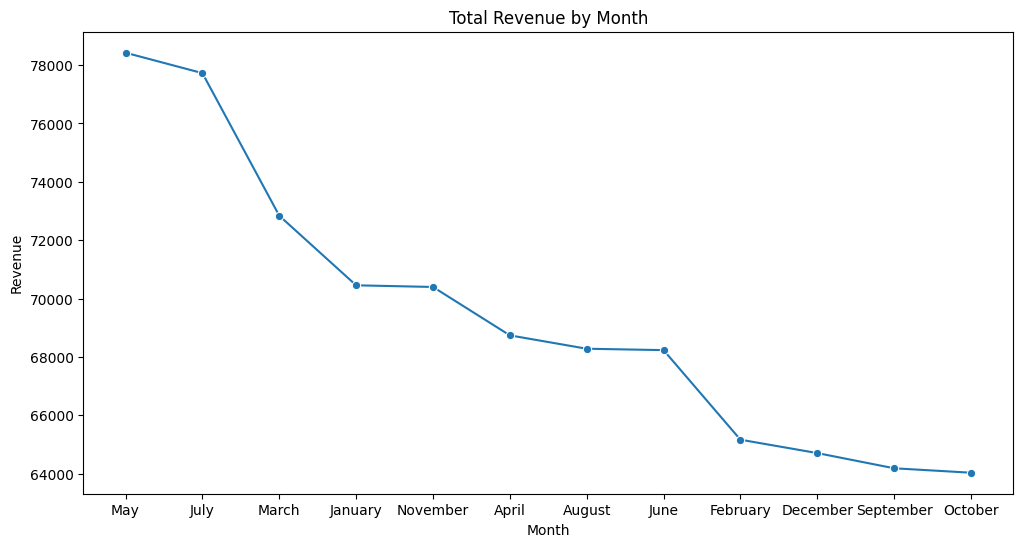

In [63]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=month_by_revenue, x='month_name', y='Revenue', marker='o')
plt.title('Total Revenue by Month')
plt.xlabel('Month')

2. Total Orders by Month

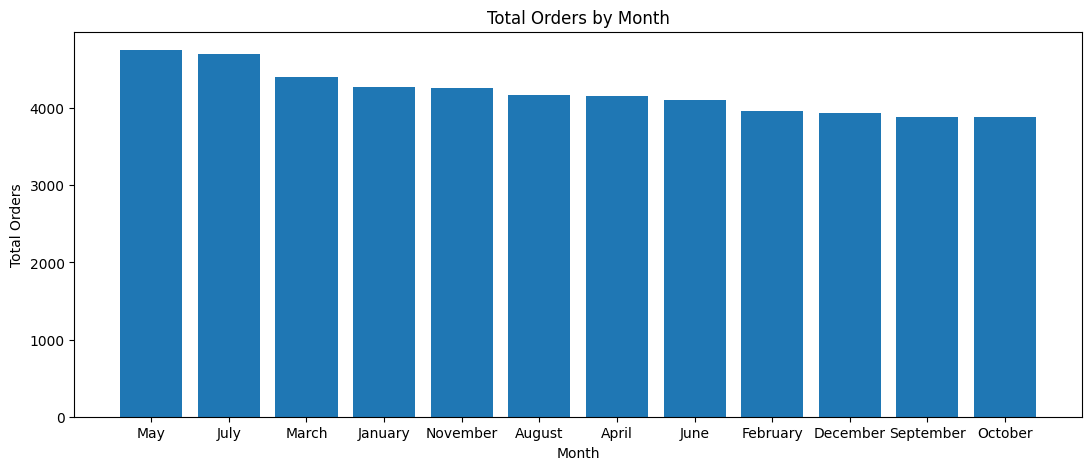

In [64]:
order_by_month = (
    df_clean
    .groupby('month_name')['quantity']
    .sum()
    .sort_values(ascending = False)
    .reset_index(name='Quantity')
)

plt.figure(figsize=(13, 5))
plt.bar(x=order_by_month['month_name'], height=order_by_month['Quantity'])
plt.title('Total Orders by Month')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.show()

3. Daily Revenue Trend

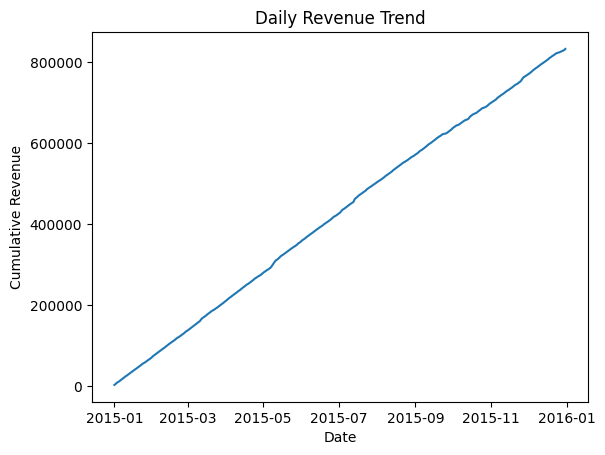

In [65]:
sns.lineplot(data=cumulative_daily_revenue, x='order_date', y='Cumulative_Revenue')
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.show()

4: Cumulative Revenue Over Time

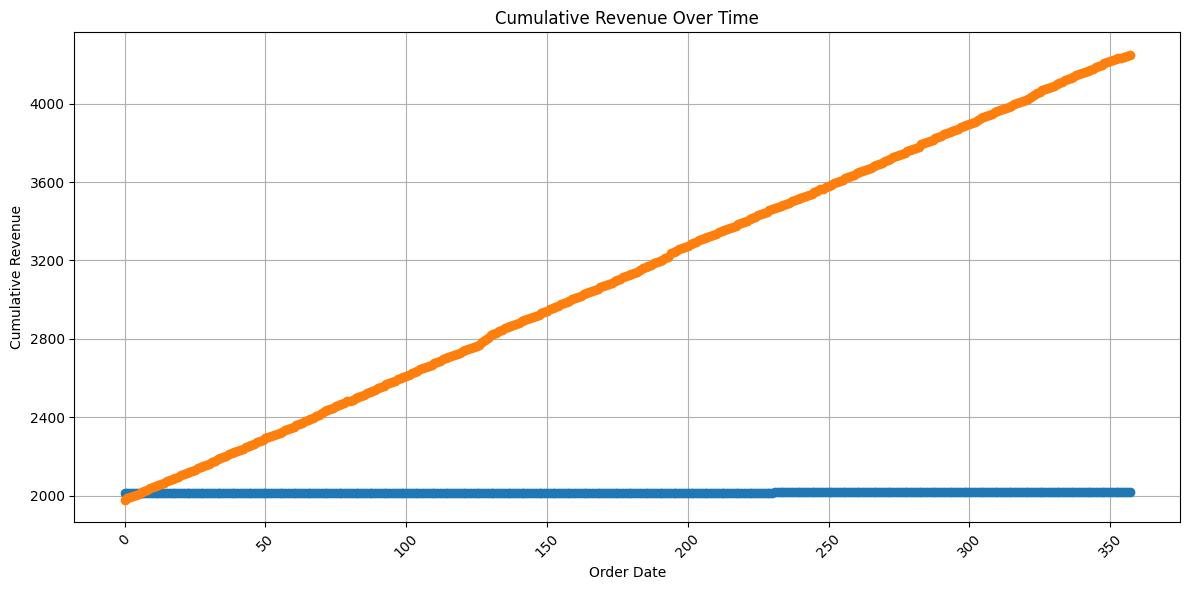

In [66]:
plt.figure(figsize=(12, 6))

plt.plot(
    cumulative_daily_revenue.index,
    cumulative_daily_revenue.values,
    marker='o',
    linewidth=2
)

plt.title('Cumulative Revenue Over Time')
plt.xlabel('Order Date')
plt.ylabel('Cumulative Revenue')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

5: Top 10 Best-Selling Pizzas

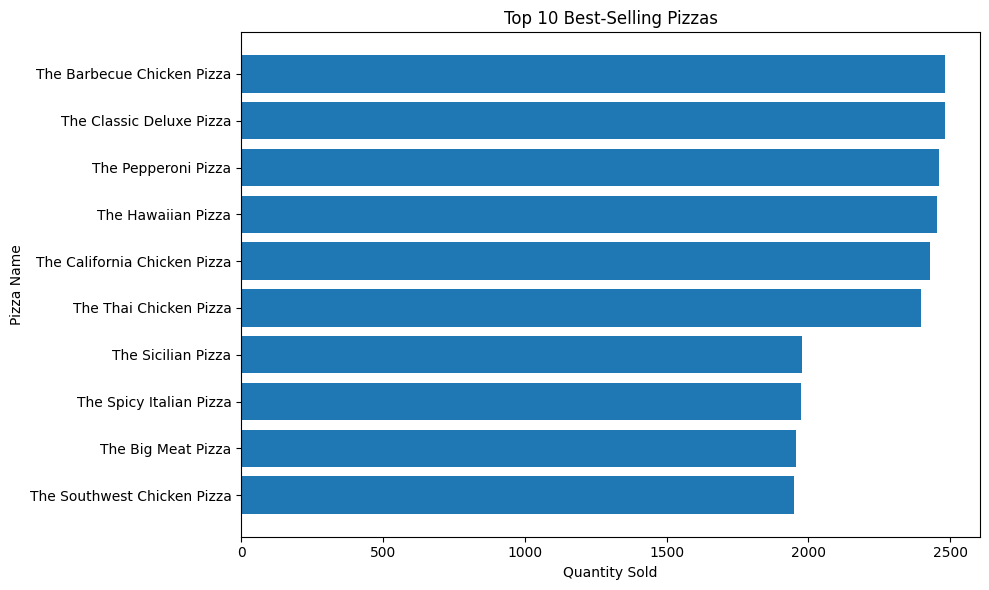

In [67]:
top_10_pizzas = (
    df_clean
    .groupby('pizza_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_10_pizzas.index,
    top_10_pizzas.values
)

plt.title('Top 10 Best-Selling Pizzas')
plt.xlabel('Quantity Sold')
plt.ylabel('Pizza Name')

plt.gca().invert_yaxis()   # Highest-selling pizza at the top

plt.tight_layout()
plt.show()

6: Bottom 10 Least-Selling Pizzas

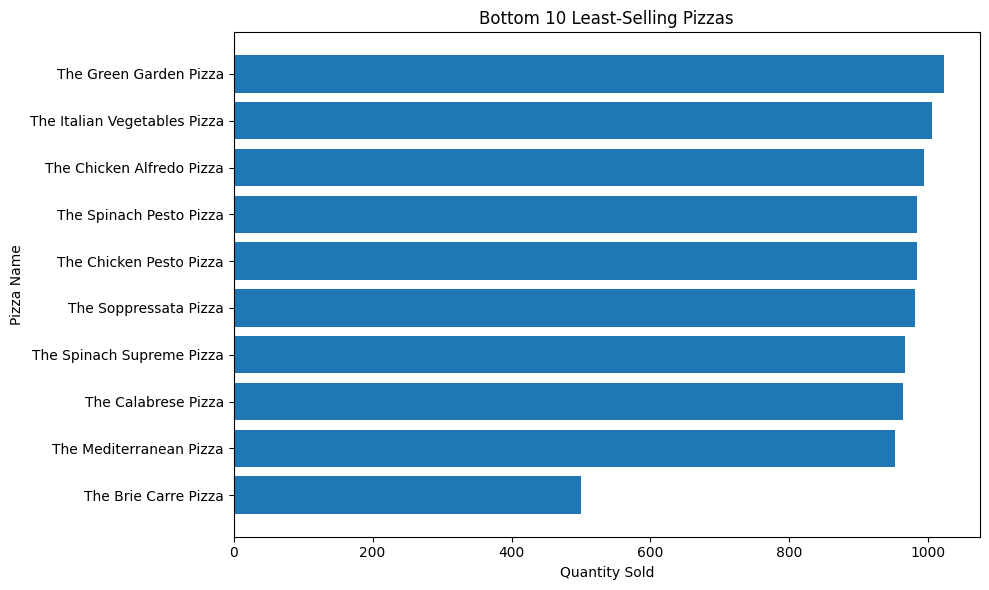

In [68]:
bottom_10_pizzas = (
    df_clean
    .groupby('pizza_name')['quantity']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    bottom_10_pizzas.index,
    bottom_10_pizzas.values
)

plt.title('Bottom 10 Least-Selling Pizzas')
plt.xlabel('Quantity Sold')
plt.ylabel('Pizza Name')

plt.tight_layout()
plt.show()

7: Revenue by Pizza Category

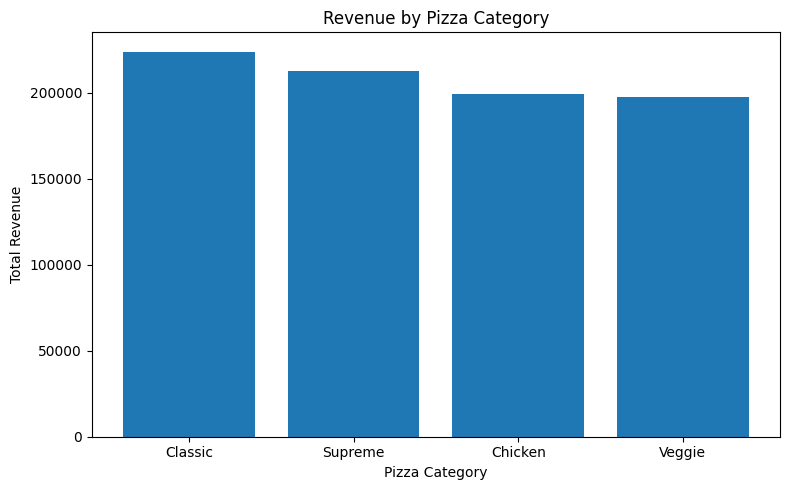

In [69]:
revenue_by_category = (
    df_clean
    .groupby('pizza_category')['total_price']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    revenue_by_category.index,
    revenue_by_category.values
)

plt.title('Revenue by Pizza Category')
plt.xlabel('Pizza Category')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

8: Revenue by Pizza Size

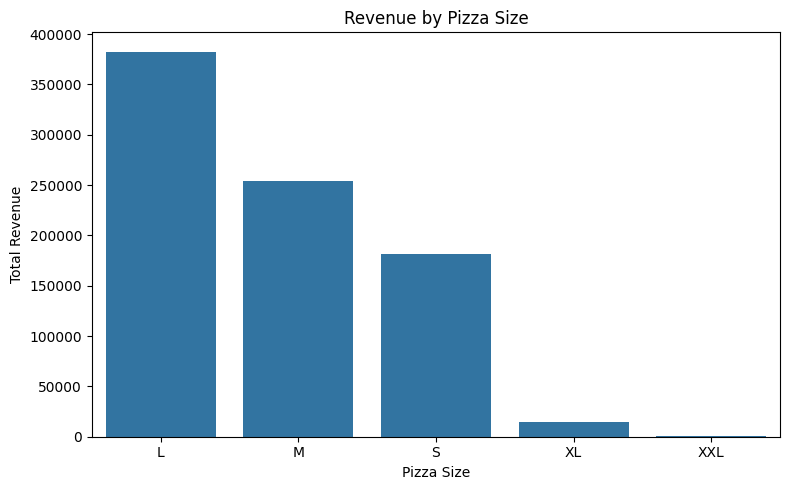

In [73]:
revenue_by_size = (
    df_clean
    .groupby('pizza_size', as_index=False)['total_price']
    .sum()
    .sort_values(by='total_price', ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_by_size,
    x='pizza_size',
    y='total_price'
)

plt.title('Revenue by Pizza Size')
plt.xlabel('Pizza Size')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

10: Orders by Day of Week

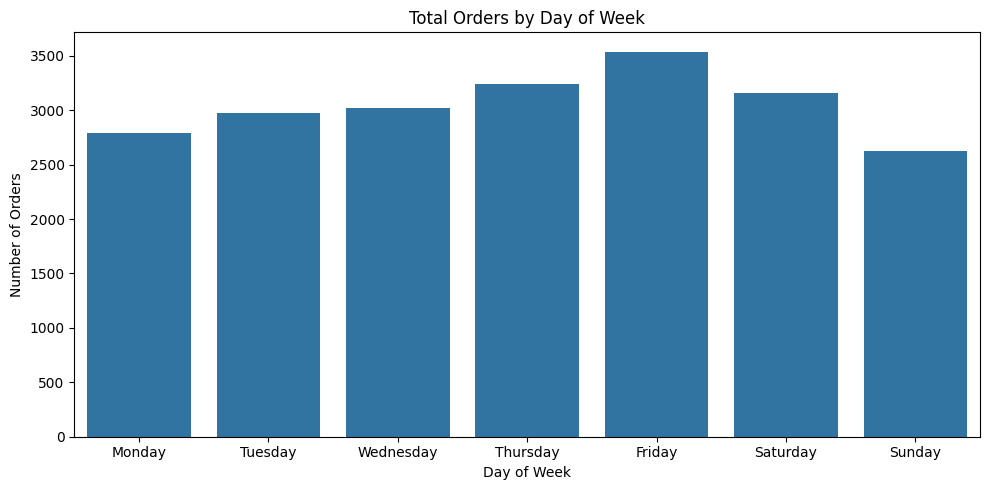

In [74]:
orders_by_day = (
    df_clean
    .groupby('day_of_week')['order_id']
    .nunique()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
    .reset_index(name='Total_Orders')
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=orders_by_day,
    x='day_of_week',
    y='Total_Orders'
)

plt.title('Total Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

11: Orders Heatmap

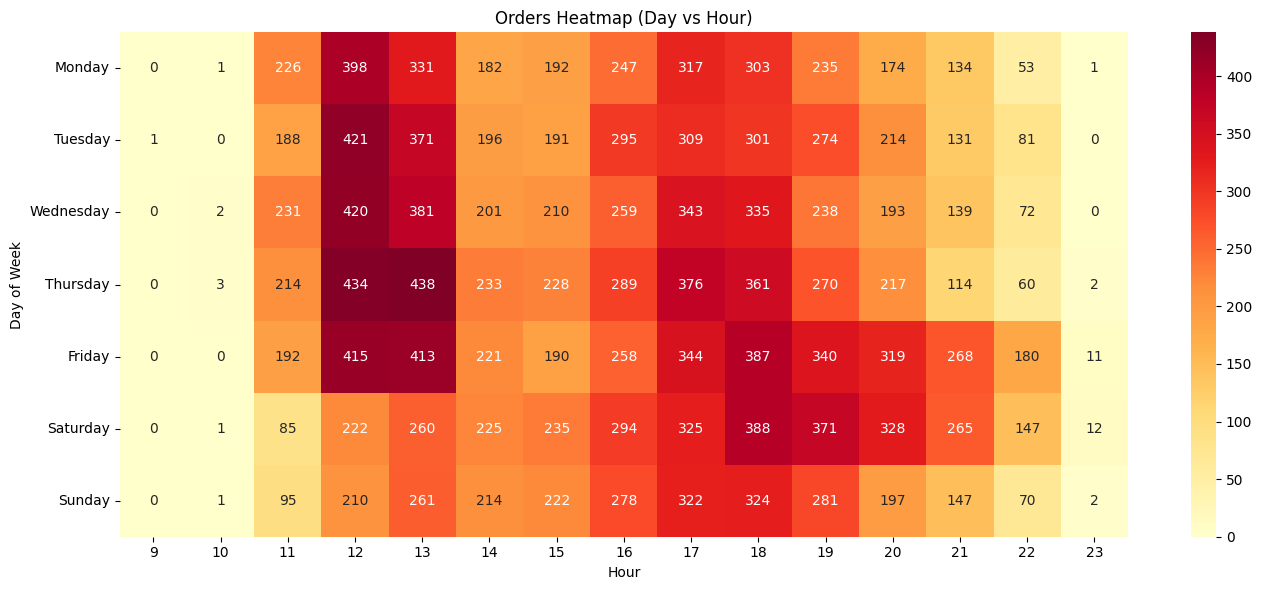

In [75]:
heatmap_data = (
    df_clean
    .groupby(['day_of_week', 'hour'])['order_id']
    .nunique()
    .unstack(fill_value=0)
    .reindex([
        'Monday','Tuesday','Wednesday',
        'Thursday','Friday','Saturday','Sunday'
    ])
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)

plt.title('Orders Heatmap (Day vs Hour)')
plt.xlabel('Hour')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

12: Revenue by Time Period

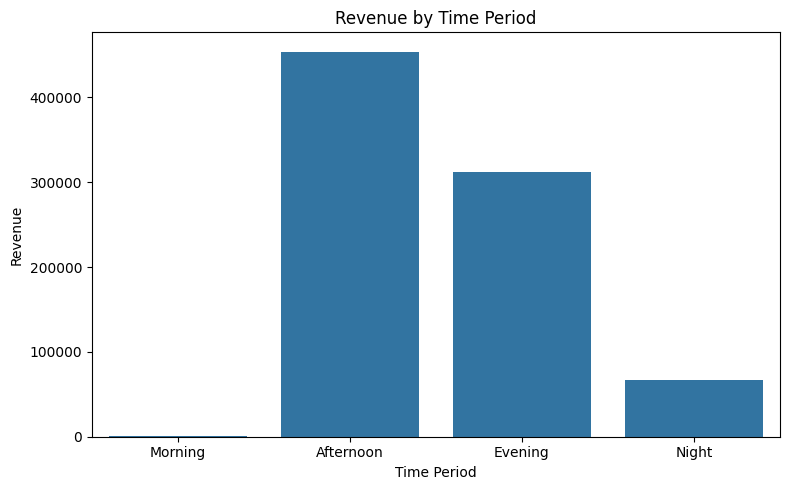

In [76]:
revenue_time = (
    df_clean
    .groupby('time_period', observed=True)['total_price']
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_time,
    x='time_period',
    y='total_price'
)

plt.title('Revenue by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

13: Top 10 Highest Revenue Pizzas

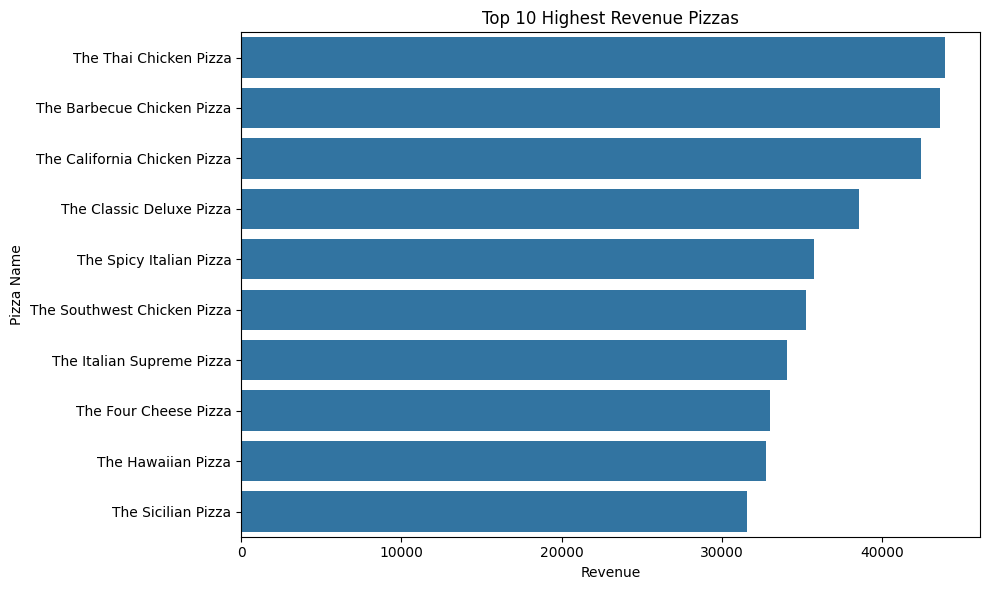

In [77]:
top_revenue = (
    df_clean
    .groupby('pizza_name')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_revenue,
    x='total_price',
    y='pizza_name'
)

plt.title('Top 10 Highest Revenue Pizzas')
plt.xlabel('Revenue')
plt.ylabel('Pizza Name')

plt.tight_layout()
plt.show()

14: Quantity vs Revenue

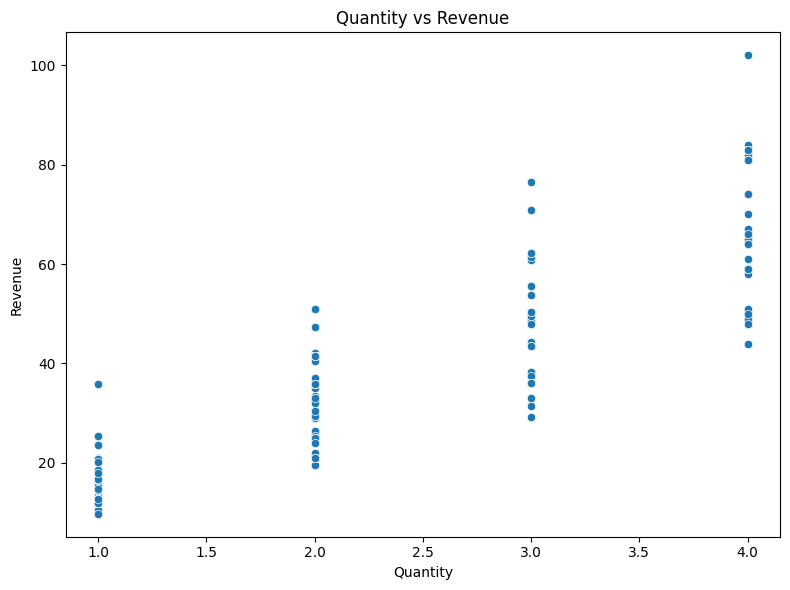

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='quantity',
    y='total_price'
)

plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()